# Lab 06 Cheatsheet
**Wavelets, Boundary (Edge) Detection, Hough Transform & SIFT** | CV Practical Lab Exam

### Contents
| # | Section | # | Section |
|---|---|---|---|
| 0 | Setup | 6 | Task 4 - Object recognition with SIFT (bounding boxes) |
| A | **Lab manual summary + manual code** | 7 | Task 5 - Panorama stitching with SIFT |
| 1 | The toolbox (big picture) | 8 | Task 6 - Lane detection (Hough lines) |
| 2 | Key API details: Hough, SIFT, wavelets | 9 | Task 7 - Coin counting (Hough circles) |
| 3 | Task 1 - Computer-screen detection (Hough lines) | 10 | Task 8 - Smart security zone (boundary detection + alarm) |
| 4 | Task 2 - Asset tracking with SIFT | 11 | Function quick reference |
| 5 | Task 3 - Sensor anomaly detection (wavelets) | 12 | Common errors & exam checklist |

**One-line recipe for every task:** `load -> grayscale -> blur -> edges (Canny) / features (SIFT) / coefficients (wavelet) -> Hough vote / RANSAC / threshold -> draw the result on the original -> print the numbers that justify it`

---
## 0. Setup
Run this cell first. Every template below is a **plain script** (flat code, `plt.subplot` display, same style as the manual). Copy a template, change the lines marked `# EDIT`, run.

**Extra install (only for Task 3 and A.5):** `pip install PyWavelets` (import name `pywt`). OpenCV has **no** wavelet transform.

The handout does not ship its images, so `lab6/images/` and `lab6/data/` hold **synthetic stand-ins** with the same properties. Replace the file names with the exam files.

| File | Stands in for | Used in |
|---|---|---|
| `images/lab_room.jpg` | photo of a computer lab: 2 rows of monitors, one missing, two switched off | Task 1, A.5 |
| `images/asset_A.jpg`, `asset_B.jpg`, `asset_C.jpg` | reference photos of three assets (C is **not** in the scene) | Tasks 2, 4 |
| `images/lab_assets_scene.jpg` | the lab shelf: A rotated, B tilted, C absent | Task 2 |
| `images/test_1.jpg` ... `test_4.jpg` | test images of asset A: larger / small + rotated / perspective + occluded / **absent** | Task 4 |
| `images/pano_1.jpg`, `pano_2.jpg`, `pano_3.jpg` | three overlapping frames while panning | Task 5 |
| `images/road.jpg` | dashboard camera frame with a white and a yellow lane line | Task 6 |
| `images/coins.jpg` | coins of different sizes, several touching | Task 7 |
| `images/security.mp4` | 75-frame camera clip: a person walks in from the left | Task 8 |
| `data/sensor_data.csv` | 1000 sensor readings with 4 spikes and a short bump | Task 3 |

**Display pattern used everywhere:**
```python
plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))   # colour (BGR -> RGB)
plt.title('Original')
plt.axis('off')
```
Gray / edge / binary images use `plt.imshow(img, cmap = 'gray')`.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pywt                                   # PyWavelets (Task 3, A.5)

plt.rcParams['figure.dpi'] = 70
os.makedirs('output', exist_ok = True)        # optional: save results here

---
# A. Lab manual summary (AI-4002, Lab 06: Wavelets, Boundary Detection, Hough Transform & SIFT)
Condensed from the manual. Sections 3-10 turn it into task templates; this part is **theory + the manual's own code**.

### A.1 Objectives
(1) Wavelet transformation, (2) boundary detection, (3) Hough transformation, (4) line detection by Hough transformation, (5) SIFT feature extraction.

### A.2 Wavelet transformation (manual section 2)
A mathematical technique that analyses a signal or image in terms of its **frequency components at different scales** (time-frequency analysis). Especially useful for **non-stationary signals** (frequency content changes over time).

| Transform | Idea | Families | Applications |
|---|---|---|---|
| **CWT** (Continuous) | continuous wavelet function `psi(t)` is **dilated (scaled) and translated** across the signal | Morlet, Mexican hat | time-frequency analysis of continuous signals: seismic signals, image analysis |
| **DWT** (Discrete) | wavelet is scaled and shifted in **discrete** steps; splits into approximation + detail coefficients | Daubechies, Haar, Symlet | image compression, **denoising**, feature extraction, signal compression |
| **WPT** (Wavelet Packet) | extension of DWT: decomposes **both** approximation and detail again, giving many subbands | same | signals with complex frequency content, feature extraction for machine learning |
| **Inverse wavelet transform** | rebuilds the signal / image from its (modified) coefficients | - | reconstruction after compression or **denoising** |

The manual's example: **original audio -> noisy audio -> cleaned audio** (DWT, shrink the small detail coefficients, inverse DWT).

### A.3 Boundary (edge) detection (section 3)
Edges = significant changes in **intensity or colour**; they carry the shape and structure of objects. Edge maps simplify the image for segmentation, recognition and feature extraction.

| Method | How it works | Output / key facts |
|---|---|---|
| **Sobel** (3.1) | gradient-based: convolve with two 3x3 kernels, one for the horizontal and one for the vertical gradient | `G = sqrt(Gx^2 + Gy^2)` = edge **strength**; direction = edge orientation |
| **Canny** (3.2) | 4 steps: (1) Gaussian smoothing, (2) gradient magnitude and direction, (3) **non-maximum suppression** (thin to 1 px), (4) **hysteresis thresholding** (strong edges kept, weak edges kept only if linked to a strong one) | thin, continuous, accurate edges; "Sobel = simple, Canny = advanced pipeline" |
| **LoG** (3.3) | Gaussian blur, then the **Laplacian (second derivative)** | edge = **zero-crossing** of the Laplacian; detects edges at varying scales |

**Sobel kernels (manual):**

| `Kx` (vertical edges) | `Ky` (horizontal edges) |
|---|---|
| `[[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]` | `[[-1, -2, -1], [0, 0, 0], [1, 2, 1]]` |

The centre row / column has weight **2** for robustness. `Kx` asks "is the right brighter than the left?", `Ky` asks "is the bottom brighter than the top?".
Worked example from the manual: a vertical edge `[200 200 200 / 50 ... 10]` gives `Gx = (1*200+2*200+1*200) - (1*50+2*50+1*50) = 800 - 40 = 760` (large response); a uniform area gives `200 - 200 = 0`.

**Derivative view (manual figure):** Canny / Sobel look for the **peak of the first derivative** (edge strength); LoG looks for the **zero-crossing of the second derivative** (edge location). Pipelines: Canny = blur -> gradient -> NMS -> hysteresis; LoG = blur -> Laplacian -> zero-crossing detection.

### A.4 Hough transform (section 4)
Detects **parametric shapes** (lines, circles) by letting every edge pixel **vote** in a parameter space; peaks = shapes. Useful where gradient edges alone cannot give a shape. Introduced by Paul Hough.

| | Lines (4.1) | Circles (4.2) |
|---|---|---|
| Equation (manual) | `y = m x + b` | `(x - a)^2 + (y - b)^2 = r^2` |
| Parameter space | `(m, b)`: each image line = one point | `(a, b, r)`: **3-D** (centre and radius) |
| Voting | for each edge pixel (from Canny) add a vote to every `(m, b)` that passes through it | each edge pixel votes for possible centres `(a, b)` and radii `r` |
| Peak detection | peaks in the accumulator = lines | peaks = circle centres and radii |
| Back-transformation | draw the detected `(m, b)` lines in the image | draw the detected circles in the image |

> **Practical note:** `y = mx + b` cannot describe a vertical line (`m` = infinity), so OpenCV uses the normal form `rho = x cos(theta) + y sin(theta)`. Same voting idea, bounded parameters.

### A.5 SIFT (section 5)
**Scale-Invariant Feature Transform:** feature extraction and matching for object recognition, image stitching and tracking.

| Step | What happens | Detail from the manual |
|---|---|---|
| 5.1 Scale-space extrema | keypoint candidates at multiple scales | **Difference of Gaussians**: `DoG = L(x,y,k*sigma) - L(x,y,sigma)` (two blurred copies subtracted) |
| 5.2 Keypoint localisation | refine the location, keep only stable points | a keypoint must be a local max / min versus its **26 neighbours** (8 same layer + 9 above + 9 below) |
| 5.3 Orientation assignment | gives **rotation invariance** | canonical orientation from the **dominant gradient direction** of the neighbourhood |
| 5.4 Descriptor generation | describes the local region | gradient histograms over sub-regions: `4 x 4 x 8 = ` **128-dimensional** vector; robust to light changes |
| 5.5 Keypoint matching | pair descriptors between images | **Euclidean distance** (or other similarity) between descriptors |
| 5.6 Outlier rejection | remove false matches | **RANSAC** fits a geometric model (affine / perspective) and discards matches that disagree |
| 5.7 Final matching and homography | the surviving matches give the transformation between the images | used for stitching and object localisation |

### A.6 The manual's code, run as given
Each cell is the manual's snippet with only the **file name** changed to a sample image. Parameters are the manual's defaults.

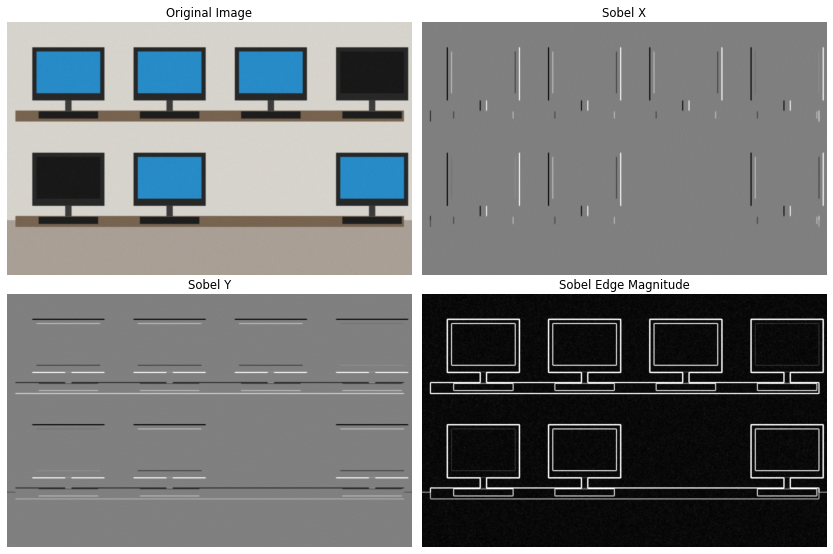

In [2]:
# ---------- MANUAL 3.1: Sobel edge detection ----------
image = cv2.imread("images/lab_room.jpg")                       # manual: "image.jpeg"
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)            # 64-bit float keeps the NEGATIVE gradients
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
magnitude = np.uint8(np.clip(magnitude, 0, 255))                # clip to 0-255 for display

plt.figure(figsize=(12, 8))
plt.subplot(2,2,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(sobel_x, cmap="gray")
plt.title("Sobel X")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(sobel_y, cmap="gray")
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(magnitude, cmap="gray")
plt.title("Sobel Edge Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()

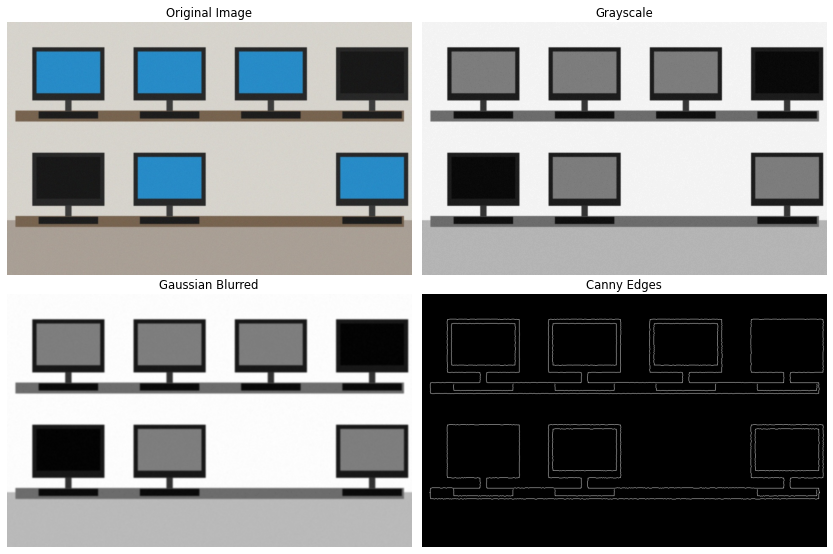

In [3]:
# ---------- MANUAL 3.2: Canny edge detection ----------
image = cv2.imread("images/lab_room.jpg")                       # manual: "image.jpg"
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (5, 5), 1.4)                   # Gaussian blur: 5x5 kernel, sigma 1.4
edges = cv2.Canny(blurred, 50, 150)                             # lower threshold 50, upper threshold 150

plt.figure(figsize=(12, 8))
plt.subplot(2,2,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blurred")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.tight_layout()
plt.show()

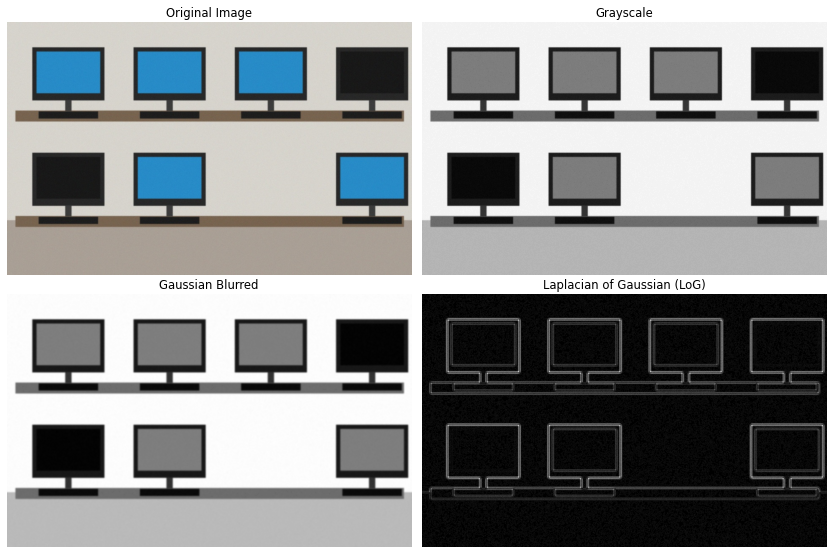

In [4]:
# ---------- MANUAL 3.3: Laplacian of Gaussian (LoG) ----------
image = cv2.imread("images/lab_room.jpg")                       # manual: "image.jpg"
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (5, 5), 1.4)                   # step 1: Gaussian blur
laplacian = cv2.Laplacian(blurred, cv2.CV_64F)                  # step 2: Laplacian (second derivative)
laplacian_abs = cv2.convertScaleAbs(laplacian)                  # absolute values for visualisation

plt.figure(figsize=(12, 8))
plt.subplot(2,2,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(blurred, cmap="gray")
plt.title("Gaussian Blurred")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(laplacian_abs, cmap="gray")
plt.title("Laplacian of Gaussian (LoG)")
plt.axis("off")

plt.tight_layout()
plt.show()

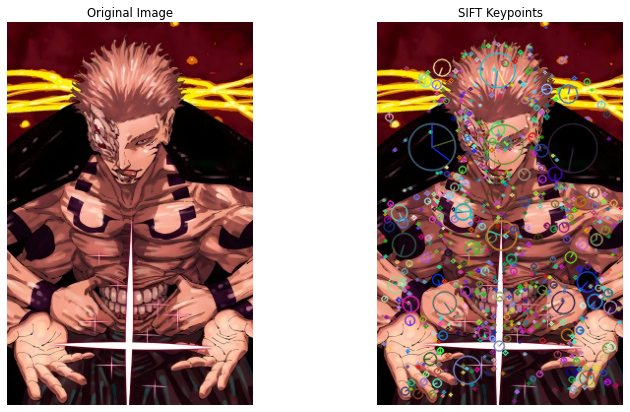

Number of keypoints: 857
Descriptor shape: (857, 128)


In [5]:
# ---------- MANUAL 5: SIFT keypoints ----------
image = cv2.imread("images/asset_B.jpg")                        # manual: "image.jpg"
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()                                        # create SIFT detector
keypoints, descriptors = sift.detectAndCompute(gray, None)      # keypoints + 128-d descriptors

image_keypoints = cv2.drawKeypoints(
    image_rgb,
    keypoints,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS            # circle size = scale, line = orientation
)

plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(image_keypoints)
plt.title("SIFT Keypoints")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Number of keypoints:", len(keypoints))
print("Descriptor shape:", descriptors.shape)                   # (number of keypoints, 128)

DWT: 1000 samples -> cA 503 + cD 503 | max reconstruction error 1.78e-15
WPT level-3 subbands: ['aaa', 'aad', 'ada', 'add', 'daa', 'dad', 'dda', 'ddd']


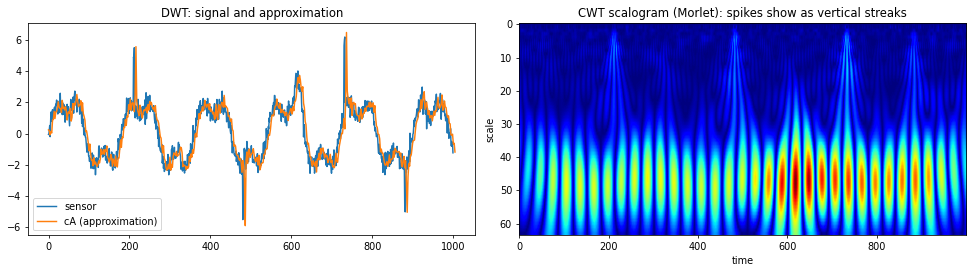

In [6]:
# ---------- THEORY CHECK (manual 2.1-2.4 has no code): DWT, inverse DWT, wavelet packet, CWT ----------
sensor = np.loadtxt('data/sensor_data.csv', skiprows = 1)

cA, cD = pywt.dwt(sensor, 'db4')                       # 2.2 one-level DWT: approximation (low) + detail (high)
rebuilt = pywt.idwt(cA, cD, 'db4')                     # 2.4 inverse DWT
print('DWT: %d samples -> cA %d + cD %d | max reconstruction error %.2e'
      % (len(sensor), len(cA), len(cD), np.abs(rebuilt[:len(sensor)] - sensor).max()))

wp = pywt.WaveletPacket(data = sensor, wavelet = 'db4', maxlevel = 3)     # 2.3 wavelet packet
print('WPT level-3 subbands:', [n.path for n in wp.get_level(3)])         # 8 subbands (DWT would give 4)

scales = np.arange(1, 65)
coef, freqs = pywt.cwt(sensor, scales, 'morl')         # 2.1 CWT with a Morlet wavelet

plt.figure(figsize = (14,4))
plt.subplot(1,2,1)
plt.plot(sensor, label = 'sensor')
plt.plot(np.arange(len(cA)) * 2, cA / np.sqrt(2), label = 'cA (approximation)')
plt.legend()
plt.title('DWT: signal and approximation')

plt.subplot(1,2,2)
plt.imshow(np.abs(coef), aspect = 'auto', cmap = 'jet')
plt.title('CWT scalogram (Morlet): spikes show as vertical streaks')
plt.xlabel('time')
plt.ylabel('scale')

plt.tight_layout()
plt.show()

### A.7 What the manual's defaults do
| Snippet | Observation |
|---|---|
| Sobel `ksize = 3`, `CV_64F` | `Sobel X` responds to **vertical** edges (monitor sides), `Sobel Y` to **horizontal** edges (desk and bezel tops); the magnitude combines both. `CV_64F` is needed, otherwise negative gradients are cut to 0 |
| Canny `(5,5), 1.4` blur and `50 / 150` | thin continuous outlines of every monitor, desk and keyboard; the textured floor / noise gives few false edges because the blur comes first |
| LoG | thicker, double-line response around every edge (the Laplacian is positive on one side of the edge and negative on the other; `convertScaleAbs` shows both). Noisier than Canny |
| SIFT `SIFT_create()` | each keypoint has position, scale, orientation; descriptors have shape `(N, 128)` |
| Manual quirk | `cv2.drawKeypoints` is called on `image_rgb`, so the keypoints are drawn on an already-RGB image and `plt.imshow` shows it correctly. If you draw on the BGR `image`, convert afterwards |

---
# 1. The toolbox (big picture)

| Tool | Finds | Needs | Key call | Typical parameters | Fails when |
|---|---|---|---|---|---|
| **Sobel** | gradient strength + direction | gray | `cv2.Sobel(g, cv2.CV_64F, dx, dy, ksize = 3)` | `ksize` | noise (no smoothing built in) |
| **Canny** | thin, connected edges | gray, blur first | `cv2.Canny(blur, low, high)` | `low`, `high` (ratio 1:2 or 1:3) | too low `low` = noise, too high `high` = broken edges |
| **LoG** | edges as zero-crossings | gray | `cv2.Laplacian(blur, cv2.CV_64F)` | blur size / sigma | noise, double edges |
| **Hough lines** | straight lines | **edge map** | `cv2.HoughLinesP(edges, rho, theta, threshold, minLineLength, maxLineGap)` | `threshold`, `minLineLength`, `maxLineGap` | curved lines, too many edges (clutter) |
| **Hough circles** | circles + radii | blurred gray | `cv2.HoughCircles(g, cv2.HOUGH_GRADIENT, dp, minDist, param1, param2, minRadius, maxRadius)` | `param2`, `minRadius`, `maxRadius`, `minDist` | non-circular shapes, wrong radius range |
| **SIFT** | scale- and rotation-invariant keypoints | gray | `sift.detectAndCompute(g, None)` | `nfeatures`, `contrastThreshold` | textureless objects, strong blur |
| **Matching + RANSAC** | which keypoints correspond, and the transform | descriptors | `BFMatcher().knnMatch` + `cv2.findHomography(.., cv2.RANSAC, 5.0)` | ratio (0.75), RANSAC threshold (3-5 px) | < 4 good matches, repetitive patterns |
| **DWT denoising** | clean signal + residual | 1-D data | `pywt.wavedec`, `pywt.threshold`, `pywt.waverec` | wavelet (`db4`), level, threshold | anomaly lasts as long as the wavelet scale |

**Which one for which task**

| Task | Tool chain |
|---|---|
| 1 Screens | Canny -> `HoughLinesP` -> split horizontal / vertical -> per-slot brightness and edge count |
| 2 Assets | SIFT per asset -> ratio test -> RANSAC homography -> inlier count decides present / absent |
| 3 Sensor | `wavedec` -> soft threshold -> `waverec` -> residual -> `k * sigma` rule |
| 4 Object recognition | SIFT + ratio test + RANSAC -> `perspectiveTransform` of the reference corners -> bounding box |
| 5 Panorama | SIFT + RANSAC homography to the **middle** image -> canvas from warped corners -> `warpPerspective` |
| 6 Lanes | Canny -> **ROI mask** -> `HoughLinesP` -> split by slope sign -> fit one line per side |
| 7 Coins | blur -> `HoughCircles` -> count = number of circles |
| 8 Security | background difference -> contours / Canny boundary -> zone overlap -> alarm |

---
# 2. Key API details: Hough, SIFT, wavelets

### Hough lines
| Function | Returns | Notes |
|---|---|---|
| `cv2.HoughLines(edges, rho, theta, threshold)` | array of `(rho, theta)` (infinite lines) | you must convert to two end points to draw: `x0 = rho*cos(theta)`, `y0 = rho*sin(theta)`, end points `(x0 +- 1000*(-sin), y0 +- 1000*cos)` |
| `cv2.HoughLinesP(edges, rho, theta, threshold, minLineLength, maxLineGap)` | array of shape `(N, 1, 4)` = `x1, y1, x2, y2` (**finite segments**) | easiest to draw: `cv2.line(img, (x1,y1), (x2,y2), colour, thickness)` |

| Parameter | Meaning | Typical |
|---|---|---|
| `rho` | accumulator distance resolution in pixels | `1` |
| `theta` | accumulator angle resolution in radians | `np.pi / 180` (1 degree) |
| `threshold` | minimum votes for a line | 50-100: **higher = fewer, longer lines** |
| `minLineLength` | shortest accepted segment (px) | 50-100 |
| `maxLineGap` | largest gap bridged between collinear points (px) | 10 for solid lines, 100+ for dashed lane markings |

### Hough circles
`circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, dp, minDist, param1 = 100, param2 = 30, minRadius = 0, maxRadius = 0)` returns shape `(1, N, 3)` = `(x, y, r)` per circle, or `None` if nothing was found.

| Parameter | Meaning | Effect |
|---|---|---|
| `dp` | inverse accumulator resolution (1 = same as image) | larger = coarser, faster |
| `minDist` | minimum distance between centres | too small = duplicates on one coin; too large = touching coins merged |
| `param1` | upper Canny threshold used inside | edge sensitivity |
| `param2` | accumulator threshold for centres | **lower = more circles (and false ones)**, higher = only strong circles |
| `minRadius`, `maxRadius` | radius range in px | outside the range = missed |

### SIFT matching pipeline (used by Tasks 2, 4, 5)
```python
sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(gray_ref, None)
kp2, des2 = sift.detectAndCompute(gray_scene, None)
pairs = cv2.BFMatcher().knnMatch(des1, des2, k = 2)               # 2 nearest neighbours per descriptor
good = [m for m, n in pairs if m.distance < 0.75 * n.distance]    # Lowe's ratio test
src = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)    # queryIdx -> image 1
dst = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)    # trainIdx -> image 2
H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)          # mask.sum() = number of inliers
```
- **Ratio test:** a match is trusted only if the best distance is clearly smaller than the second best (< 0.75). Removes ambiguous matches.
- **RANSAC:** repeatedly fits a homography to 4 random matches and keeps the model that most matches agree with; matches that disagree are **outliers**. `mask.ravel() == 1` marks the inliers.
- **Decision rule:** object present if inliers >= about 10 (state your number).
- **Bounding polygon:** `corners = np.float32([[0,0],[w,0],[w,h],[0,h]]).reshape(-1,1,2)`; `cv2.perspectiveTransform(corners, H)` gives where the reference lands in the scene.

### Wavelets (PyWavelets)
| Call | Purpose |
|---|---|
| `pywt.dwt(x, 'db4')` / `pywt.idwt(cA, cD, 'db4')` | one-level DWT and its inverse |
| `coeffs = pywt.wavedec(x, 'db4', level = 4)` | multi-level DWT: `[cA4, cD4, cD3, cD2, cD1]` (**cD1 = finest / highest frequency**) |
| `pywt.threshold(c, value, mode = 'soft')` | shrink small coefficients to 0 (`'soft'` also shrinks the large ones by `value`, `'hard'` keeps them) |
| `pywt.waverec(coeffs, 'db4')` | inverse multi-level DWT (output can be 1 sample longer: slice `[:len(x)]`) |
| `pywt.cwt(x, scales, 'morl')` | continuous transform, returns `(coefficients, frequencies)` |
| `pywt.WaveletPacket(data = x, wavelet = 'db4', maxlevel = 3)` | wavelet packet tree |

**Denoising recipe:** noise level `sigma = median(|cD1|) / 0.6745`; universal threshold `thr = sigma * sqrt(2 ln N)`; soft-threshold every **detail** level (keep `cA`); reconstruct.

---
# 3. Task 1 - Computer-screen detection (Hough lines)
**Scenario:** monitor the lab by finding the boundaries of the computer screens, then report each screen's status (on / off) and any missing screen.

| Step | What | Call |
|---|---|---|
| 1 | Load, grayscale, blur | `cv2.cvtColor`, `cv2.GaussianBlur(gray, (5,5), 0)` |
| 2 | Edge map (Hough needs edges, not intensities) | `cv2.Canny(blur, 50, 150)` |
| 3 | Line segments | `cv2.HoughLinesP(edges, 1, np.pi/180, 80, minLineLength = 100, maxLineGap = 10)` |
| 4 | Split into horizontal and vertical lines | `abs(y2 - y1) < 5` -> horizontal, `abs(x2 - x1) < 5` -> vertical |
| 5 | Draw the lines on the original | `cv2.line(out, (x1,y1), (x2,y2), (0,255,0), 2)` |
| 6 | Per slot: **edge pixels** (missing?) and **mean brightness** of the screen area (on / off?) | `np.count_nonzero(edges[y0:y1, x0:x1])`, `gray[...].mean()` |

**Model answers**
- *Why Canny before Hough?* The Hough transform votes with **edge pixels**; feeding it a gray image would make every pixel vote. Canny keeps only the boundary pixels, so the accumulator peaks come from real straight edges.
- *How is a missing screen detected?* The slot has **almost no edge pixels** (no bezel, no stand), whereas an occupied slot has long horizontal and vertical Hough lines.
- *How is on / off detected?* A switched-on screen is bright inside its bezel (mean about 117 in gray here), a switched-off screen is near black (about 25). A threshold of about 70 separates them.

**Pitfalls**
- `HoughLinesP` returns `None` when nothing is found: check `if lines is not None`.
- Each line has shape `(1, 4)`: use `for line in lines: x1, y1, x2, y2 = line[0]`.
- Too low `threshold` / `minLineLength` gives many short spurious lines (the keyboard keys, speckle).
- `maxLineGap` bridges the stand behind a bezel edge; too large joins lines across different monitors.

lines found: 38 (horizontal 28, vertical 10)
slot 1 at ( 60, 60): edge pixels  604, brightness 116.4 -> ON
slot 2 at (300, 60): edge pixels  605, brightness 116.4 -> ON
slot 3 at (540, 60): edge pixels  611, brightness 116.4 -> ON
slot 4 at (780, 60): edge pixels  110, brightness  24.5 -> OFF
slot 5 at ( 60,310): edge pixels  101, brightness  24.5 -> OFF
slot 6 at (300,310): edge pixels  601, brightness 116.4 -> ON
slot 7 at (540,310): edge pixels    0, brightness 211.6 -> MISSING
slot 8 at (780,310): edge pixels  613, brightness 116.5 -> ON


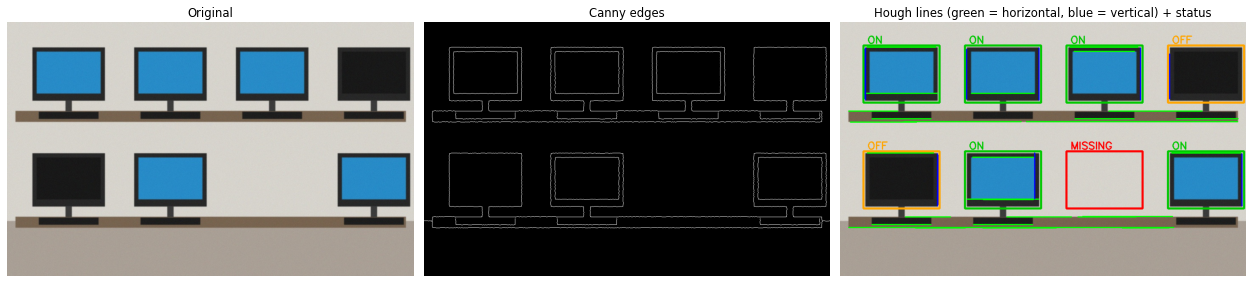

In [7]:
# ---------- TEMPLATE: screen boundaries with Hough lines + status check ----------
image = cv2.imread('images/lab_room.jpg')                                 # EDIT: lab photo
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)                                       # EDIT: thresholds

lines = cv2.HoughLinesP(edges, 1, np.pi / 180, 80, minLineLength = 100, maxLineGap = 10)   # EDIT: threshold, length, gap

output = image.copy()
n_h = 0
n_v = 0
for line in lines:
    x1, y1, x2, y2 = line[0]
    if abs(y2 - y1) < 5:                                                  # horizontal edge
        cv2.line(output, (x1, y1), (x2, y2), (0, 255, 0), 2)
        n_h += 1
    elif abs(x2 - x1) < 5:                                                # vertical edge
        cv2.line(output, (x1, y1), (x2, y2), (255, 0, 0), 2)
        n_v += 1
print('lines found: %d (horizontal %d, vertical %d)' % (len(lines), n_h, n_v))

# status per monitor slot: top-left corner (x0, y0) read from the picture; a monitor is 170 x 125 px
slots = [(60, 60), (300, 60), (540, 60), (780, 60),
         (60, 310), (300, 310), (540, 310), (780, 310)]                   # EDIT: slot positions
for i, (x0, y0) in enumerate(slots):
    edge_pixels = np.count_nonzero(edges[y0:y0 + 125, x0:x0 + 170])       # bezel / stand edges inside the slot
    brightness = gray[y0 + 15:y0 + 105, x0 + 15:x0 + 155].mean()          # inside the bezel
    if edge_pixels < 50:
        status, colour = 'MISSING', (0, 0, 255)
    elif brightness > 70:                                                 # EDIT: on / off threshold
        status, colour = 'ON', (0, 200, 0)
    else:
        status, colour = 'OFF', (0, 165, 255)
    cv2.rectangle(output, (x0 - 5, y0 - 5), (x0 + 175, y0 + 130), colour, 3)
    cv2.putText(output, status, (x0 + 5, y0 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, colour, 2)
    print('slot %d at (%3d,%3d): edge pixels %4d, brightness %5.1f -> %s' % (i + 1, x0, y0, edge_pixels, brightness, status))

cv2.imwrite('output/task1_screens.png', output)

plt.figure(figsize = (18,6))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(edges, cmap = 'gray')
plt.title('Canny edges')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title('Hough lines (green = horizontal, blue = vertical) + status')
plt.axis('off')

plt.tight_layout()
plt.show()

---
# 4. Task 2 - Asset tracking with SIFT
**Scenario:** recognise individual assets (computers, monitors, keyboards ...) in a photo of the lab by matching each asset's reference picture against the scene, to keep an inventory.

| Step | What | Call |
|---|---|---|
| 1 | Load the scene and every reference asset (gray) | `cv2.imread(path, cv2.IMREAD_GRAYSCALE)` |
| 2 | Keypoints + descriptors for the scene (once) | `sift.detectAndCompute(scene, None)` |
| 3 | For **each asset**: keypoints, descriptors | same call |
| 4 | k-NN matching + Lowe ratio test (0.75) | `bf.knnMatch(des_a, des_s, k = 2)` |
| 5 | RANSAC homography, count **inliers** | `cv2.findHomography(src, dst, cv2.RANSAC, 5.0)` |
| 6 | Inliers >= 10 -> asset **present**: outline it with `perspectiveTransform` | `cv2.polylines(...)` |
| 7 | Print the inventory table | asset, keypoints, good matches, inliers, verdict |

**Model answers**
- *Why SIFT for assets?* Its keypoints are **invariant to scale and rotation** and robust to lighting, so the same asset is recognised whatever its distance and tilt in the photo.
- *Why the ratio test?* Without it many descriptors match the wrong place (ambiguous, repeated texture). Only matches whose best distance is clearly below the second best (< 0.75) are kept.
- *Why RANSAC?* Even good matches contain a few wrong pairs. RANSAC keeps only the matches that agree with **one** geometric transformation; the inlier count is a robust confidence score.
- *How is an absent asset recognised?* Few good matches and **almost no inliers** (asset C here has only 4); a present asset has 100+.

**Pitfalls**
- `knnMatch` needs `k = 2` for the ratio test; unpack as `for m, n in pairs`.
- `queryIdx` indexes the **first** descriptor set (asset), `trainIdx` the second (scene). Mixing them gives garbage.
- `findHomography` needs **at least 4** matches, otherwise it returns `None`; check before using `mask`.
- Reference and scene must both be **gray** (or at least the same type) for `detectAndCompute`.

Asset  Keypoints  Good matches  Inliers   Verdict
A      186        106           103       PRESENT
B      846        563           556       PRESENT
C      454        6             4         absent


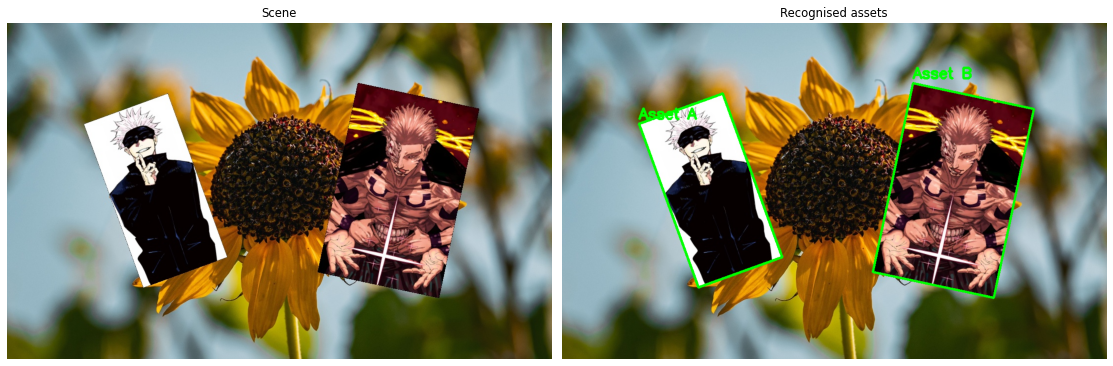

In [8]:
# ---------- TEMPLATE: SIFT asset recognition (inventory table) ----------
scene_color = cv2.imread('images/lab_assets_scene.jpg')                   # EDIT: scene photo
scene = cv2.cvtColor(scene_color, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
bf = cv2.BFMatcher()
kp_s, des_s = sift.detectAndCompute(scene, None)                          # scene features (computed once)

assets = ['A', 'B', 'C']                                                  # EDIT: reference images asset_<x>.jpg
output = scene_color.copy()
print('%-6s %-10s %-13s %-9s %s' % ('Asset', 'Keypoints', 'Good matches', 'Inliers', 'Verdict'))

for name in assets:
    ref = cv2.imread('images/asset_%s.jpg' % name, cv2.IMREAD_GRAYSCALE)
    kp_a, des_a = sift.detectAndCompute(ref, None)

    pairs = bf.knnMatch(des_a, des_s, k = 2)
    good = []
    for m, n in pairs:
        if m.distance < 0.75 * n.distance:                                # Lowe's ratio test
            good.append(m)

    inliers = 0
    if len(good) >= 4:
        src = np.float32([kp_a[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst = np.float32([kp_s[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
        if H is not None:
            inliers = int(mask.sum())

    present = inliers >= 10                                               # EDIT: decision threshold
    print('%-6s %-10d %-13d %-9d %s' % (name, len(kp_a), len(good), inliers, 'PRESENT' if present else 'absent'))

    if present:
        h, w = ref.shape
        corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
        box = cv2.perspectiveTransform(corners, H)                        # where the asset lands in the scene
        cv2.polylines(output, [np.int32(box)], True, (0, 255, 0), 4)
        cv2.putText(output, 'Asset ' + name, tuple(np.int32(box[0, 0]) + [0, -10]), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 3)

cv2.imwrite('output/task2_assets.png', output)

plt.figure(figsize = (16,6))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(scene_color, cv2.COLOR_BGR2RGB))
plt.title('Scene')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title('Recognised assets')
plt.axis('off')

plt.tight_layout()
plt.show()

---
# 5. Task 3 - Sensor anomaly detection (wavelets)
**Scenario:** industrial machines stream sensor readings. Use the wavelet transform to separate the normal signal from noise and flag abnormal patterns.

**Expected output (handout):** two stacked plots: (1) *Sensor Data and Denoised Signal* (both curves), (2) *Residuals and Detected Anomalies* (residual curve + anomaly markers); x axis = sample index 0-1000.

| Step | What | Call |
|---|---|---|
| 1 | Load the data | `np.loadtxt('data/sensor_data.csv', skiprows = 1)` |
| 2 | Decompose | `coeffs = pywt.wavedec(sensor, 'db4', level = 4)` |
| 3 | Estimate the noise level from the finest detail band | `sigma = np.median(np.abs(coeffs[-1])) / 0.6745` |
| 4 | Universal threshold | `thr = sigma * np.sqrt(2 * np.log(len(sensor)))` |
| 5 | Soft-threshold every **detail** band (keep `coeffs[0]`) | `pywt.threshold(c, thr, mode = 'soft')` |
| 6 | Reconstruct the denoised signal | `pywt.waverec(...)[:len(sensor)]` |
| 7 | Residual = original - denoised | `residual = sensor - denoised` |
| 8 | Anomaly = residual larger than `k` robust standard deviations | `np.abs(residual) > k * res_sigma` |
| 9 | Plot both panels, mark anomalies, print where they are | `plt.plot`, `plt.scatter` |

**Model answers**
- *Why wavelets and not a plain low-pass filter?* Wavelet coefficients are **localised in time and scale**: a short spike lives in a few fine-scale coefficients at one position, while the slow oscillation lives in the coarse bands. Thresholding removes noise but keeps the signal shape; a Fourier filter spreads a spike over all frequencies.
- *Why do anomalies appear in the residual?* The denoised signal follows the **normal smooth pattern**; whatever the model cannot explain (sudden spikes) stays in `original - denoised`. Large residual = abnormal.
- *Why a robust sigma (median / 0.6745)?* The mean and standard deviation are themselves inflated by the anomalies; the median-based estimate is not.
- *Effect of `k`:* small `k` flags noise (false positives), large `k` misses small anomalies. About 3-4 is typical; state and justify your value.

**Pitfalls**
- `waverec` can return **one sample too many**: slice `[:len(sensor)]` or the subtraction fails.
- Threshold the **detail** bands only; thresholding `coeffs[0]` flattens the signal.
- `'hard'` thresholding keeps large coefficients unchanged (spikes survive, residual is small); `'soft'` shrinks them (spikes leave a residual): that is what makes them detectable here.
- One event produces several consecutive flagged samples: group them with `np.diff(idx) > gap`.

wavelet db4, level 4 | noise sigma 0.351 | threshold 1.306 | residual sigma 0.355 | k = 4
anomalous samples: 8, grouped into 4 events
  event at samples 210 - 212 (peak residual 1.93)
  event at samples 480 - 482 (peak residual -1.79)
  event at samples 730 - 732 (peak residual 1.73)
  event at samples 880 - 881 (peak residual -2.05)


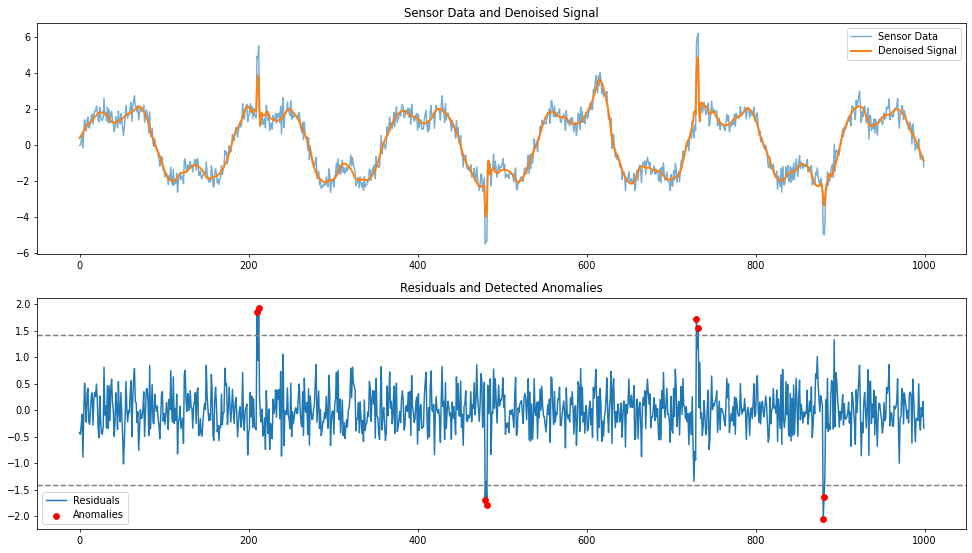

In [9]:
# ---------- TEMPLATE: wavelet denoising + residual anomaly detection ----------
sensor = np.loadtxt('data/sensor_data.csv', skiprows = 1)                 # EDIT: dataset
n = len(sensor)

wavelet = 'db4'                                                           # EDIT: wavelet family
level = 4                                                                 # EDIT: decomposition level
coeffs = pywt.wavedec(sensor, wavelet, level = level)                     # [cA4, cD4, cD3, cD2, cD1]

sigma = np.median(np.abs(coeffs[-1])) / 0.6745                            # noise level from the finest band
thr = sigma * np.sqrt(2 * np.log(n))                                      # universal threshold
den_coeffs = [coeffs[0]]                                                  # keep the approximation untouched
for c in coeffs[1:]:
    den_coeffs.append(pywt.threshold(c, thr, mode = 'soft'))              # shrink the detail bands
denoised = pywt.waverec(den_coeffs, wavelet)[:n]

residual = sensor - denoised
res_sigma = np.median(np.abs(residual - np.median(residual))) / 0.6745    # robust spread of the residual
k = 4                                                                     # EDIT: sensitivity
anomalies = np.where(np.abs(residual) > k * res_sigma)[0]

# group neighbouring samples into events
if len(anomalies) > 0:
    events = np.split(anomalies, np.where(np.diff(anomalies) > 5)[0] + 1)
else:
    events = []
print('wavelet %s, level %d | noise sigma %.3f | threshold %.3f | residual sigma %.3f | k = %d' % (wavelet, level, sigma, thr, res_sigma, k))
print('anomalous samples: %d, grouped into %d events' % (len(anomalies), len(events)))
for e in events:
    print('  event at samples %d - %d (peak residual %.2f)' % (e[0], e[-1], residual[e][np.argmax(np.abs(residual[e]))]))

plt.figure(figsize = (14,8))
plt.subplot(2,1,1)
plt.plot(sensor, label = 'Sensor Data', alpha = 0.6)
plt.plot(denoised, label = 'Denoised Signal', linewidth = 2)
plt.title('Sensor Data and Denoised Signal')
plt.legend()

plt.subplot(2,1,2)
plt.plot(residual, label = 'Residuals')
plt.axhline(k * res_sigma, color = 'gray', linestyle = '--')
plt.axhline(-k * res_sigma, color = 'gray', linestyle = '--')
plt.scatter(anomalies, residual[anomalies], color = 'red', label = 'Anomalies', zorder = 3)
plt.title('Residuals and Detected Anomalies')
plt.legend()

plt.tight_layout()
plt.savefig('output/task3_wavelet.png')
plt.show()

---
# 6. Task 4 - Object recognition with SIFT (bounding boxes)
**Scenario:** you have **one reference image** of the object and several test images. Locate the object in each test image even when it is larger / smaller, rotated, partly hidden, or not there at all.

| Step | What | Call |
|---|---|---|
| 1 | Reference keypoints + descriptors (**once**, outside the loop) | `sift.detectAndCompute(ref, None)` |
| 2 | For each test image: keypoints, descriptors | same |
| 3 | `knnMatch(k = 2)` + ratio test 0.75 | as in Task 2 |
| 4 | RANSAC homography, inlier count | `cv2.findHomography(..., cv2.RANSAC, 5.0)` |
| 5 | Inliers >= 10: project the reference corners | `cv2.perspectiveTransform(corners, H)` |
| 6 | Draw the box | `cv2.polylines` (tight outline) or `cv2.boundingRect` + `cv2.rectangle` (axis-aligned) |
| 7 | Not enough inliers: report **not found** | print / title |

**Video version:** the handout title says "using video". Do steps 1 once, then put steps 2-6 inside `cap = cv2.VideoCapture(path)` / `while True: ok, frame = cap.read(); if not ok: break`. Computing the reference features inside the loop wastes time.

**Model answers**
- *Why does it work at different scales and rotations?* SIFT finds keypoints in a **scale space** (Difference of Gaussians) and assigns each a **dominant orientation**, so the descriptor is measured relative to that scale and angle. The same physical point gets (almost) the same 128-d descriptor.
- *Why does it survive partial occlusion?* Recognition needs only a **few dozen** matching keypoints, not the whole object. Hidden regions simply contribute no matches; RANSAC still finds the transformation from the visible part.
- *Why is the box a quadrilateral, not a rectangle?* A homography includes perspective, so the reference rectangle maps to a general quadrilateral. Use `cv2.boundingRect` on its points for an upright rectangle.
- *Why decide with inliers, not raw matches?* Wrong objects still produce a handful of random matches; only a true object produces many matches that **agree geometrically**.

**Pitfalls**
- Draw on a **colour copy** of the test image (not the gray one).
- A bad homography can give a self-intersecting box: check `inliers`, not just `H is not None`.
- Very small references (few keypoints) cannot reach the inlier threshold.

larger                   keypoints  759 | good matches 107 | inliers 104 -> FOUND
small + rotated          keypoints 1082 | good matches  63 | inliers  51 -> FOUND


perspective + occluded   keypoints  857 | good matches  65 | inliers  47 -> FOUND
object absent            keypoints 1700 | good matches  13 | inliers   5 -> not found


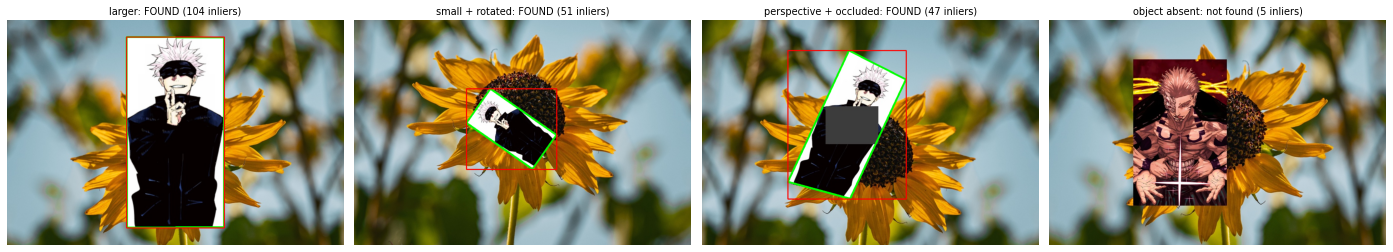

In [10]:
# ---------- TEMPLATE: object recognition in several test images ----------
ref_color = cv2.imread('images/asset_A.jpg')                              # EDIT: reference object
ref = cv2.cvtColor(ref_color, cv2.COLOR_BGR2GRAY)
h, w = ref.shape
corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)

sift = cv2.SIFT_create()
bf = cv2.BFMatcher()
kp_r, des_r = sift.detectAndCompute(ref, None)                            # reference features, once

test_files = ['images/test_1.jpg', 'images/test_2.jpg', 'images/test_3.jpg', 'images/test_4.jpg']     # EDIT
titles = ['larger', 'small + rotated', 'perspective + occluded', 'object absent']                    # EDIT

plt.figure(figsize = (20,5))
for i, path in enumerate(test_files):
    test_color = cv2.imread(path)
    test = cv2.cvtColor(test_color, cv2.COLOR_BGR2GRAY)
    kp_t, des_t = sift.detectAndCompute(test, None)

    pairs = bf.knnMatch(des_r, des_t, k = 2)
    good = [m for m, n in pairs if m.distance < 0.75 * n.distance]

    inliers = 0
    if len(good) >= 4:
        src = np.float32([kp_r[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst = np.float32([kp_t[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
        if H is not None:
            inliers = int(mask.sum())

    result = test_color.copy()
    if inliers >= 10:                                                     # EDIT: decision threshold
        box = cv2.perspectiveTransform(corners, H)
        cv2.polylines(result, [np.int32(box)], True, (0, 255, 0), 4)                   # tight outline
        x, y, bw, bh = cv2.boundingRect(np.int32(box))
        cv2.rectangle(result, (x, y), (x + bw, y + bh), (0, 0, 255), 2)                # upright bounding box
        verdict = 'FOUND'
    else:
        verdict = 'not found'
    print('%-24s keypoints %4d | good matches %3d | inliers %3d -> %s' % (titles[i], len(kp_t), len(good), inliers, verdict))
    cv2.imwrite('output/task4_result_%d.png' % (i + 1), result)

    plt.subplot(1,4,i + 1)
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title('%s: %s (%d inliers)' % (titles[i], verdict, inliers), fontsize = 10)
    plt.axis('off')

plt.tight_layout()
plt.show()

---
# 7. Task 5 - Panorama stitching with SIFT
**Scenario:** frames taken while panning overlap. Match SIFT keypoints between neighbouring frames, estimate the homography, and warp everything into one panoramic image.

| Step | What | Call |
|---|---|---|
| 1 | Load the frames in left-to-right order | `cv2.imread` |
| 2 | Choose the **middle** frame as the reference plane | `base = imgs[1]` |
| 3 | For each other frame: SIFT, ratio test, RANSAC homography **frame -> base** | `cv2.findHomography(src_frame, dst_base, cv2.RANSAC, 5.0)` |
| 4 | Warped corners of all frames -> canvas bounds | `cv2.perspectiveTransform(corners, H)`; `min` / `max` |
| 5 | Translation so nothing is at negative coordinates | `shift = [[1,0,-xmin],[0,1,-ymin],[0,0,1]]` |
| 6 | Warp each frame with `shift @ H` onto the canvas | `cv2.warpPerspective(img, shift @ H, (W, H))` |
| 7 | Paste: outer frames first, the base last | boolean mask of non-black pixels |

**Model answers**
- *Why a homography?* Frames of a (nearly) planar or distant scene taken from one camera position differ by a projective transformation, so 4+ matches determine how to map one image into the other.
- *Why the middle image as reference?* The error accumulates with each warp; warping outer frames directly into the centre frame keeps distortion symmetric and small. Chaining 1->2->3 doubles the drift on frame 3.
- *Why RANSAC?* A few wrong SIFT matches would distort the homography; RANSAC rejects them.
- *Why is a seam visible?* Exposure differs between frames and no blending is applied. A feather blend (see Lab 3 Task 9) hides it; alignment is the goal here.

**Pitfalls**
- Direction: `src` = points in the frame being warped, `dst` = the same points in the **base**.
- Forgetting the `shift` translation cuts off everything that lands left of / above the base.
- Use `shift @ H` (matrix product, **right-to-left**: H first, then shift).
- Frames need 30-50 % overlap; very little overlap gives too few inliers.
- A one-line OpenCV alternative exists (`cv2.Stitcher_create().stitch(imgs)`), but the task asks you to implement it with SIFT.

frame 1 -> base: 594 good matches, 592 inliers
frame 3 -> base: 793 good matches, 784 inliers
panorama canvas (w, h): (1540, 890)


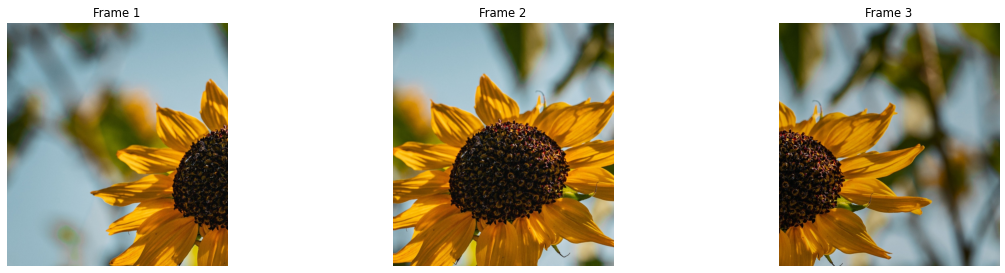

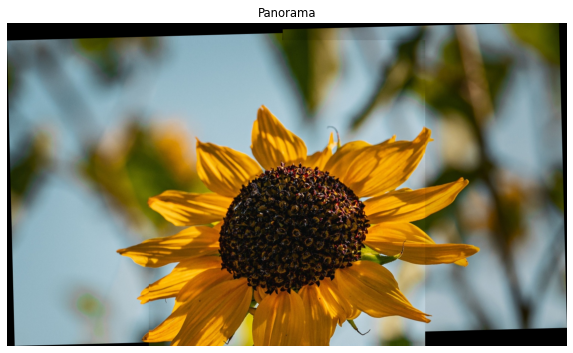

In [11]:
# ---------- TEMPLATE: SIFT panorama (middle frame is the reference) ----------
imgs = [cv2.imread('images/pano_%d.jpg' % i) for i in (1, 2, 3)]          # EDIT: frames, left to right
base_index = 1                                                            # the middle frame
base = imgs[base_index]

sift = cv2.SIFT_create()
bf = cv2.BFMatcher()
kp_b, des_b = sift.detectAndCompute(cv2.cvtColor(base, cv2.COLOR_BGR2GRAY), None)

Hs = []                                                                   # homography frame -> base
for i, img in enumerate(imgs):
    if i == base_index:
        Hs.append(np.eye(3))
        continue
    kp, des = sift.detectAndCompute(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), None)
    pairs = bf.knnMatch(des, des_b, k = 2)
    good = [m for m, n in pairs if m.distance < 0.75 * n.distance]
    src = np.float32([kp[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)          # points in this frame
    dst = np.float32([kp_b[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)        # same points in the base
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    print('frame %d -> base: %d good matches, %d inliers' % (i + 1, len(good), mask.sum()))
    Hs.append(H)

# canvas bounds from the warped corners of every frame
all_corners = []
for img, H in zip(imgs, Hs):
    h, w = img.shape[:2]
    c = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
    all_corners.append(cv2.perspectiveTransform(c, H))
all_corners = np.concatenate(all_corners)
x_min, y_min = np.int32(all_corners.min(axis = 0).ravel() - 0.5)
x_max, y_max = np.int32(all_corners.max(axis = 0).ravel() + 0.5)
shift = np.array([[1, 0, -x_min],
                  [0, 1, -y_min],
                  [0, 0, 1]], float)
size = (int(x_max - x_min), int(y_max - y_min))                           # (width, height)
print('panorama canvas (w, h):', size)

panorama = np.zeros((size[1], size[0], 3), np.uint8)
for i in (0, 2, base_index):                                              # outer frames first, base last (wins in overlaps)
    warped = cv2.warpPerspective(imgs[i], shift @ Hs[i], size)
    mask = warped.sum(axis = 2) > 0
    panorama[mask] = warped[mask]

cv2.imwrite('output/task5_panorama.png', panorama)

plt.figure(figsize = (18,4))
for i, img in enumerate(imgs):
    plt.subplot(1,3,i + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Frame %d' % (i + 1))
    plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize = (16,6))
plt.imshow(cv2.cvtColor(panorama, cv2.COLOR_BGR2RGB))
plt.title('Panorama')
plt.axis('off')
plt.show()

---
# 8. Task 6 - Lane detection (Hough lines)
**Scenario:** from the vehicle's camera image, find the lane lines and draw them to support lane-keeping.

| Step | What | Call |
|---|---|---|
| 1 | Grayscale + blur | `cv2.cvtColor`, `cv2.GaussianBlur(gray, (5,5), 0)` |
| 2 | Canny edges | `cv2.Canny(blur, 50, 150)` |
| 3 | **Region of interest**: keep only the road in front (triangle / trapezoid) | `cv2.fillPoly(mask, [polygon], 255)`, `cv2.bitwise_and(edges, mask)` |
| 4 | Hough segments | `cv2.HoughLinesP(roi, 1, np.pi/180, 50, minLineLength = 60, maxLineGap = 150)` |
| 5 | Split into **left** / **right** by slope sign | `slope = (y2 - y1) / (x2 - x1)`; `slope < 0` -> left, `> 0` -> right (image y points down) |
| 6 | Fit one line per side through all its end points | `np.polyfit(ys, xs, 1)` -> `x = m*y + c` |
| 7 | Draw from the bottom of the image up to a fixed `y` | `cv2.line` on a blank layer, then `cv2.addWeighted` |

**Model answers**
- *Why the region of interest?* The whole image contains buildings, sky and car edges that also produce straight lines; masking everything except the road removes them before the Hough vote (the sample image gives 18 lines without the mask, 13 with it).
- *Why split by slope sign?* Lane lines converge to a vanishing point: the **left** lane rises to the right (negative slope in image coordinates, because y points down), the **right** lane has a positive slope. Near-horizontal lines (`|slope| < 0.3`) and near-vertical ones (`|slope| > 2`, e.g. the dashed centre line, which would otherwise pull the fit sideways) are not lane markings.
- *Why fit one line per side?* Hough returns many short fragments (dashed marking, broken paint). Fitting `x = m*y + c` through all their points gives one stable lane line for the controller.
- *Why large `maxLineGap`?* Dashed centre lines have gaps; a big gap joins the dashes into one segment.

**Pitfalls**
- Fit `x` as a function of `y` (not `y` of `x`): lane lines are nearly vertical, so slopes in `y = mx + b` blow up.
- Skip vertical segments (`x1 == x2`) when computing `slope` (division by zero).
- The ROI polygon must be tuned to the camera: it is a list of `(x, y)` points in an extra pair of brackets, `np.array([[p1, p2, p3, p4]])`.
- `cv2.addWeighted(image, 0.8, line_layer, 1, 0)` overlays the lane lines semi-transparently.

Hough segments in the ROI: 13
left lane: x = -1.722*y + 1050.8  (from (120, 540) to (430, 360))
right lane: x = 1.724*y + -90.3  (from (840, 540) to (530, 360))


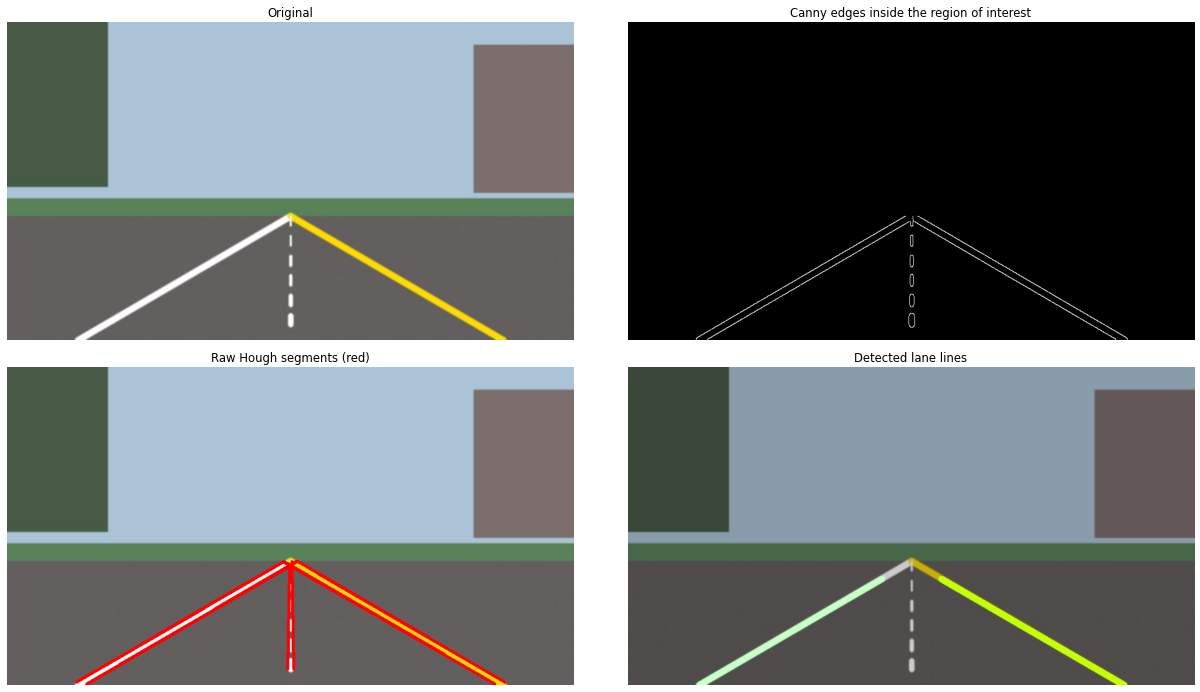

In [12]:
# ---------- TEMPLATE: lane detection ----------
image = cv2.imread('images/road.jpg')                                     # EDIT: road image
h, w = image.shape[:2]
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)

roi_mask = np.zeros_like(edges)
polygon = np.array([[(0, h), (w, h), (520, 330), (440, 330)]])            # EDIT: road region (bottom-left, bottom-right, top-right, top-left)
cv2.fillPoly(roi_mask, polygon, 255)
roi_edges = cv2.bitwise_and(edges, roi_mask)

lines = cv2.HoughLinesP(roi_edges, 1, np.pi / 180, 50, minLineLength = 60, maxLineGap = 150)    # EDIT: parameters
print('Hough segments in the ROI:', len(lines))

left_x, left_y, right_x, right_y = [], [], [], []
raw = image.copy()
for line in lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(raw, (x1, y1), (x2, y2), (0, 0, 255), 3)                     # every raw segment
    if x2 == x1:
        continue                                                          # vertical: slope undefined
    slope = (y2 - y1) / (x2 - x1)
    if abs(slope) < 0.3 or abs(slope) > 2:
        continue                                                          # not a lane: nearly horizontal, or nearly vertical (dashed centre line)
    if slope < 0:                                                         # left lane
        left_x += [x1, x2]
        left_y += [y1, y2]
    else:                                                                 # right lane
        right_x += [x1, x2]
        right_y += [y1, y2]

lane_layer = np.zeros_like(image)
y_top = 360                                                               # EDIT: how far up the lane lines are drawn
for xs, ys, colour, name in ((left_x, left_y, (0, 255, 0), 'left'), (right_x, right_y, (0, 255, 0), 'right')):
    if len(xs) > 0:
        m, c = np.polyfit(ys, xs, 1)                                      # x = m*y + c
        p1 = (int(m * h + c), h)
        p2 = (int(m * y_top + c), y_top)
        cv2.line(lane_layer, p1, p2, colour, 10)
        print('%s lane: x = %.3f*y + %.1f  (from %s to %s)' % (name, m, c, p1, p2))
    else:
        print(name, 'lane: NOT found')

result = cv2.addWeighted(image, 0.8, lane_layer, 1, 0)                    # overlay on the original
cv2.imwrite('output/task6_lanes.png', result)

plt.figure(figsize = (18,10))
plt.subplot(2,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(roi_edges, cmap = 'gray')
plt.title('Canny edges inside the region of interest')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB))
plt.title('Raw Hough segments (red)')
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title('Detected lane lines')
plt.axis('off')

plt.tight_layout()
plt.show()

---
# 9. Task 7 - Coin counting (Hough circles)
**Scenario:** automatically find and count coins of different sizes and positions.

| Step | What | Call |
|---|---|---|
| 1 | Grayscale + **median blur** (removes noise, keeps edges) | `cv2.medianBlur(gray, 5)` |
| 2 | Circle Hough transform | `cv2.HoughCircles(blur, cv2.HOUGH_GRADIENT, dp = 1.2, minDist = 40, param1 = 100, param2 = 30, minRadius = 25, maxRadius = 65)` |
| 3 | Round the results | `np.uint16(np.around(circles))` |
| 4 | Draw outline and centre; number the coins | `cv2.circle(...)`, `cv2.putText(...)` |
| 5 | Count | `circles.shape[1]` (or `len(circles[0])`) |
| 6 | Parameter study | repeat with different `param2`, radius range, `minDist` |

**Model answers**
- *Why Hough instead of thresholding + contours?* Touching coins form one blob after thresholding (count too low). Hough finds each circle from its **curved edge**, so partly overlapping or touching coins are still separate circles.
- *Role of the radius range:* constrains the 3-D accumulator `(a, b, r)`; coins outside the range are missed, too wide a range is slower and adds false circles.
- *Role of `param2`:* the vote threshold. **Lower = more circles, including false ones on texture; higher = only strong circles, small or partly visible coins are lost.**
- *Role of `minDist`:* stops several circles being reported on one coin (too small) or neighbouring coins being suppressed (too large).

**Pitfalls**
- `HoughCircles` returns `None` when nothing is found: check before `circles.shape`.
- The result has shape `(1, N, 3)`: use `circles[0]` to iterate `(x, y, r)`.
- Coordinates are floats: convert to `int` before `cv2.circle`.
- Blur first, otherwise noise creates false circles; on large images downsize for speed and scale radii accordingly.

coins counted: 17
radii found (px): min 31, max 59

setting                            circles
param2 = 10 (very low)             28
param2 = 30 (used)                 17
param2 = 60 (high)                 16
minRadius 40 (misses small coins)  12
minDist 5 (duplicates allowed)     88


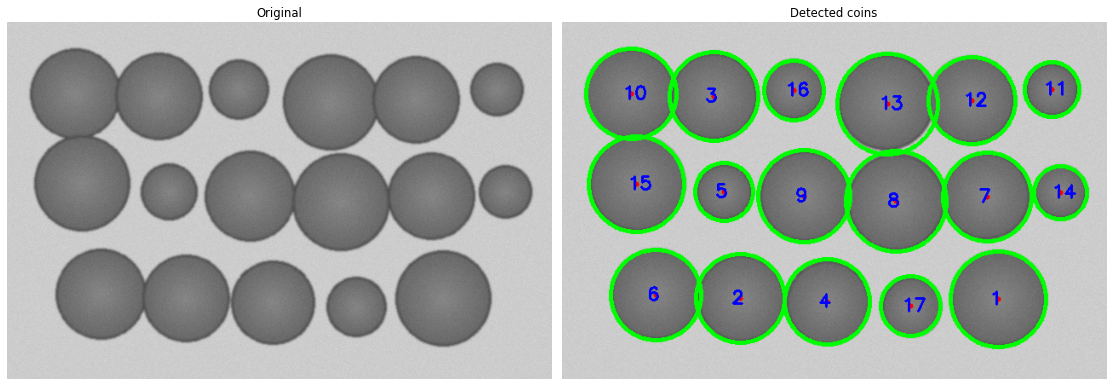

In [13]:
# ---------- TEMPLATE: Hough circle coin counting + parameter study ----------
image = cv2.imread('images/coins.jpg')                                    # EDIT: coin image
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.medianBlur(gray, 5)

circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, dp = 1.2, minDist = 40,
                           param1 = 100, param2 = 30, minRadius = 25, maxRadius = 65)     # EDIT: parameters

output = image.copy()
if circles is not None:
    circles = np.uint16(np.around(circles))
    for i, (x, y, r) in enumerate(circles[0], 1):
        cv2.circle(output, (x, y), r, (0, 255, 0), 3)                     # coin outline
        cv2.circle(output, (x, y), 3, (0, 0, 255), -1)                    # centre
        cv2.putText(output, str(i), (x - 10, y + 6), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
    print('coins counted:', circles.shape[1])
    print('radii found (px): min %d, max %d' % (circles[0][:, 2].min(), circles[0][:, 2].max()))
cv2.imwrite('output/task7_coins.png', output)

# parameter study: how many circles does each setting give?
print('\n%-34s %s' % ('setting', 'circles'))
for label, kw in (('param2 = 10 (very low)', dict(param2 = 10)),
                  ('param2 = 30 (used)', dict(param2 = 30)),
                  ('param2 = 60 (high)', dict(param2 = 60)),
                  ('minRadius 40 (misses small coins)', dict(param2 = 30, minRadius = 40)),
                  ('minDist 5 (duplicates allowed)', dict(param2 = 30, minDist = 5))):
    p = dict(dp = 1.2, minDist = 40, param1 = 100, param2 = 30, minRadius = 25, maxRadius = 65)
    p.update(kw)
    c = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, **p)
    print('%-34s %d' % (label, 0 if c is None else c.shape[1]))

plt.figure(figsize = (16,6))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title('Detected coins')
plt.axis('off')

plt.tight_layout()
plt.show()

---
# 10. Task 8 - Smart security zone (boundary detection + alarm)
**Scenario:** watch a video stream; when an unauthorised object enters a protected zone, trigger an alarm. Use boundary detection to find the object's outline.

| Step | What | Call |
|---|---|---|
| 1 | Open the stream | `cap = cv2.VideoCapture('images/security.mp4')` (or `0` for a webcam) |
| 2 | Read the first frame as the **empty-scene reference** | `ok, first = cap.read()`; gray + `GaussianBlur` |
| 3 | Loop over frames | `while True: ok, frame = cap.read(); if not ok: break` |
| 4 | Difference from the reference | `cv2.absdiff(blur, background)` |
| 5 | Binary motion mask | `cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)`, `cv2.dilate` to close holes |
| 6 | **Boundary of the object** | `cv2.Canny(mask, 50, 150)` and/or `cv2.findContours` + `cv2.boundingRect` |
| 7 | Zone test: boundary pixels inside the zone | `np.count_nonzero(edges[y1:y2, x1:x2]) > N` |
| 8 | Alarm: red zone + text, record the frame number | `cv2.rectangle`, `cv2.putText` |
| 9 | Release | `cap.release()` |

**Model answers**
- *How is the boundary detected?* The absolute difference to the empty-scene frame keeps only changed pixels; Canny on that mask outlines the intruder. Any outline pixels inside the zone rectangle mean the object has entered.
- *Why compare with a reference frame?* The background is static, so anything that differs is a new object. (For changing backgrounds use `cv2.createBackgroundSubtractorMOG2()`.)
- *Why blur and threshold the difference?* Sensor noise changes every pixel by a few gray levels; blur + threshold 30 ignore that.
- *Why require several boundary pixels (N) instead of one?* Avoids a false alarm from a single noisy pixel.

**Pitfalls**
- The first frame must contain **no intruder**; otherwise the intruder becomes background.
- `cap.read()` returns `(False, None)` at the end: always test `ok`.
- Lighting changes over a long video break a fixed reference; update or use MOG2.
- Always `cap.release()` (and `cv2.destroyAllWindows()` if you used `imshow`). In a notebook use `plt` instead of `cv2.imshow` + `waitKey(0)`.
- Use `cv2.VideoWriter` only if an output video is required; here a few saved frames are enough.

frames processed: 74
first alarm at frame: 45
frame 10:    0 boundary pixels in the zone -> clear
frame 35:    0 boundary pixels in the zone -> clear
frame 50:  195 boundary pixels in the zone -> ALARM
frame 70:  181 boundary pixels in the zone -> ALARM


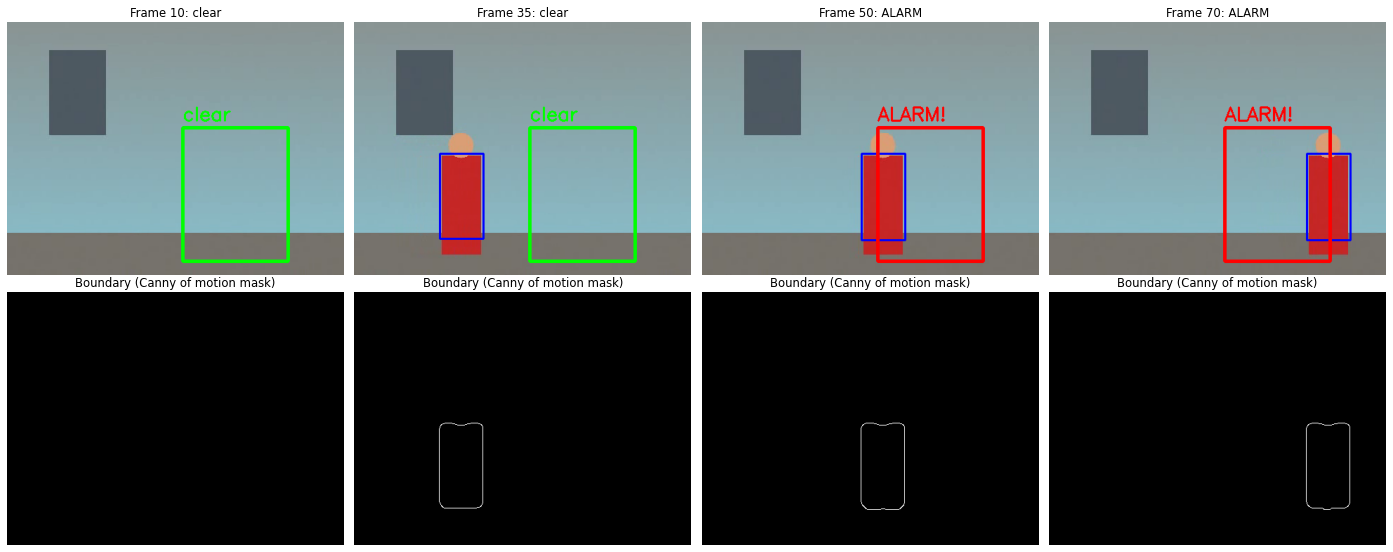

In [14]:
# ---------- TEMPLATE: security zone with background difference + Canny boundary ----------
cap = cv2.VideoCapture('images/security.mp4')                             # EDIT: video file (or 0 = webcam)

ok, first = cap.read()                                                    # reference frame: empty scene
background = cv2.GaussianBlur(cv2.cvtColor(first, cv2.COLOR_BGR2GRAY), (21, 21), 0)

x1, y1, x2, y2 = 250, 150, 400, 340                                       # EDIT: protected zone (top-left, bottom-right)
min_boundary_pixels = 50                                                  # EDIT: boundary pixels needed to raise the alarm
show_frames = [10, 35, 50, 70]                                            # frames to display
shown = []
first_alarm = None

frame_no = 0
while True:
    ok, frame = cap.read()
    if not ok:
        break
    frame_no += 1

    gray = cv2.GaussianBlur(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), (21, 21), 0)
    diff = cv2.absdiff(gray, background)                                  # what changed?
    ret, motion = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)
    motion = cv2.dilate(motion, None, iterations = 2)

    edges = cv2.Canny(motion, 50, 150)                                    # boundary of the moving object
    in_zone = np.count_nonzero(edges[y1:y2, x1:x2])                       # boundary pixels inside the zone
    alarm = in_zone > min_boundary_pixels
    if alarm and first_alarm is None:
        first_alarm = frame_no

    contours, hierarchy = cv2.findContours(motion, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    out = frame.copy()
    for c in contours:
        if cv2.contourArea(c) > 500:                                      # ignore tiny blobs
            bx, by, bw, bh = cv2.boundingRect(c)
            cv2.rectangle(out, (bx, by), (bx + bw, by + bh), (255, 0, 0), 2)
    colour = (0, 0, 255) if alarm else (0, 255, 0)                        # red = alarm, green = clear
    cv2.rectangle(out, (x1, y1), (x2, y2), colour, 3)
    cv2.putText(out, 'ALARM!' if alarm else 'clear', (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, colour, 2)

    if frame_no in show_frames:
        shown.append((frame_no, out, edges, in_zone, alarm))

cap.release()
print('frames processed:', frame_no)
print('first alarm at frame:', first_alarm)
for f, o, e, n, a in shown:
    print('frame %2d: %4d boundary pixels in the zone -> %s' % (f, n, 'ALARM' if a else 'clear'))

cv2.imwrite('output/task8_alarm_frame.png', shown[-2][1])

plt.figure(figsize = (20,8))
for i, (f, o, e, n, a) in enumerate(shown):
    plt.subplot(2,4,i + 1)
    plt.imshow(cv2.cvtColor(o, cv2.COLOR_BGR2RGB))
    plt.title('Frame %d: %s' % (f, 'ALARM' if a else 'clear'))
    plt.axis('off')

    plt.subplot(2,4,i + 5)
    plt.imshow(e, cmap = 'gray')
    plt.title('Boundary (Canny of motion mask)')
    plt.axis('off')

plt.tight_layout()
plt.show()

---
# 11. Function quick reference

| Function | Signature / notes |
|---|---|
| `cv2.Sobel(g, cv2.CV_64F, dx, dy, ksize = 3)` | gradient along x (`dx=1, dy=0`) or y; **64-bit float** to keep negatives |
| `cv2.Canny(g, low, high)` | thin edges; hysteresis with two thresholds |
| `cv2.Laplacian(g, cv2.CV_64F)` | second derivative; apply to a blurred image for LoG |
| `cv2.convertScaleAbs(a)` | absolute value, scaled to `uint8` |
| `cv2.GaussianBlur(g, (5,5), sigma)` / `cv2.medianBlur(g, 5)` | noise removal (median for salt-and-pepper, circles) |
| `cv2.HoughLinesP(edges, rho, theta, threshold, minLineLength, maxLineGap)` | segments `(N, 1, 4)` or `None` |
| `cv2.HoughLines(edges, rho, theta, threshold)` | infinite lines `(rho, theta)` |
| `cv2.HoughCircles(g, cv2.HOUGH_GRADIENT, dp, minDist, param1, param2, minRadius, maxRadius)` | `(1, N, 3)` or `None` |
| `cv2.fillPoly(mask, polygon, 255)` | filled polygon (ROI mask); `polygon` is `np.array([[(x,y), ...]])` |
| `cv2.bitwise_and(a, b)` | keep pixels where the mask is 255 |
| `cv2.line / cv2.circle / cv2.rectangle / cv2.polylines / cv2.putText` | drawing on a colour image (BGR colours) |
| `cv2.addWeighted(a, alpha, b, beta, gamma)` | blend two images (overlay) |
| `cv2.SIFT_create()` -> `sift.detectAndCompute(g, None)` | keypoints + `(N, 128)` descriptors |
| `cv2.drawKeypoints(img, kp, None, flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)` | visualise keypoints |
| `cv2.BFMatcher().knnMatch(des1, des2, k = 2)` | two nearest neighbours per descriptor |
| `cv2.findHomography(src, dst, cv2.RANSAC, 5.0)` | `(H, mask)`; `mask.sum()` = inliers |
| `cv2.perspectiveTransform(pts, H)` | `pts` shape `(N, 1, 2)` float32 |
| `cv2.warpPerspective(img, H, (w, h))` | warp onto a canvas `(width, height)` |
| `cv2.boundingRect(points)` | upright box `(x, y, w, h)` |
| `cv2.absdiff(a, b)` | per-pixel absolute difference |
| `cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)` | outlines of white regions |
| `cv2.VideoCapture(path)` -> `cap.read()` -> `(ok, frame)`; `cap.release()` | video loop |
| `pywt.wavedec / waverec / threshold / dwt / idwt / cwt` | see section 2 |
| `np.polyfit(y, x, 1)` | straight-line fit, returns `(slope, intercept)` |
| `np.loadtxt(path, skiprows = 1)` | read a CSV of numbers |

---
# 12. Common errors & exam checklist

| Symptom | Cause | Fix |
|---|---|---|
| `TypeError: 'NoneType' object is not iterable` after `HoughLinesP` / `HoughCircles` | nothing was detected (returned `None`) | lower `threshold` / `param2`, check the edge map, add `if lines is not None` |
| Hundreds of tiny Hough lines | threshold or `minLineLength` too low, no blur | raise them, blur first, add an ROI |
| Hough gets lines from sky / buildings | no region of interest | mask the road region with `fillPoly` |
| `cv2.line` raises a type error | end points are NumPy ints/floats of the wrong type | `int(x1)` or `tuple(map(int, ...))` |
| Coin count too high | `param2` too low, `minDist` too small | raise `param2`, set `minDist` about one coin radius |
| Coin count too low | radius range wrong, `param2` too high | check `minRadius` / `maxRadius` against real radii |
| `cv2.error` in `drawKeypoints` | image/keypoints from different images | draw on the image the keypoints came from |
| `knnMatch` result unpack error | forgot `k = 2` | `knnMatch(d1, d2, k = 2)` then `for m, n in pairs` |
| Bounding box in the wrong place | swapped `queryIdx` / `trainIdx`, or swapped src / dst | `queryIdx` -> first image, `trainIdx` -> second |
| `findHomography` returns `None` | fewer than 4 good matches | lower ratio strictness (0.8), check overlap, use better images |
| Panorama has a missing left part | no `shift` translation | add `shift = T(-xmin, -ymin)` and use `shift @ H` |
| Panorama is a heap of garbage | homography direction reversed | `src` = frame being warped, `dst` = base |
| `ValueError: operands could not be broadcast` in wavelets | `waverec` output is 1 longer | slice `[:len(signal)]` |
| No anomalies found | `k` too large or `'hard'` thresholding | smaller `k`, `'soft'` mode |
| Everything flagged as anomaly | `k` too small / residual sigma not robust | `k` 3-4, use median-based sigma |
| `ModuleNotFoundError: pywt` | PyWavelets missing | `pip install PyWavelets` |
| Notebook freezes on video | `cv2.imshow` + `waitKey(0)` | show frames with `plt.imshow` |
| `cap.read()` loop never ends | forgot `if not ok: break` | test `ok` |
| Colours wrong in `plt.imshow` | BGR vs RGB | `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` |

### Exam checklist
1. Read the scenario, pick the tool from the table in section 1 (lines -> Hough lines, circles -> Hough circles, object/stitch -> SIFT, signal -> wavelet, video -> `VideoCapture` loop).
2. Pre-process: grayscale + blur (median for circles) + Canny before any Hough call.
3. Remove clutter with an ROI or radius range before voting.
4. For SIFT: ratio test 0.75, RANSAC 5.0, decide by **inliers**, draw with `perspectiveTransform`.
5. Show **original and result** side by side with titles; print counts / inliers / thresholds.
6. State your parameters and why (one line each) and answer the "why does it work" question using the model answers.
7. Check `None` results, `ok` flags, array shapes and BGR/RGB before submitting.